In [8]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
# data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv("survey_data.csv")

# Display the first few rows of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


Identify respondents with extremely high yearly compensation.

In [9]:
df = df.dropna(subset=['ConvertedCompYearly','WorkExp','JobSat'])

# Calculate basic statistics
mean_comp = df['ConvertedCompYearly'].mean()
median_comp = df['ConvertedCompYearly'].median()
std_dev_comp = df['ConvertedCompYearly'].std()

# Define the threshold for high compensation (3 standard deviations above the mean)
threshold = mean_comp + (3 * std_dev_comp)
# Identify respondents with extremely high compensation
high_earners = df[df['ConvertedCompYearly'] > threshold]

# Display the statistics
stats_summary = pd.DataFrame({
    "Metric": ["Mean", "Median", "Standard Deviation", "Threshold (Mean + 3*STD)"],
    "Value": [mean_comp, median_comp, std_dev_comp, threshold]
})

stats_summary




,Metric,Value
0,Mean,86074.771257
1,Median,66066.000000
2,Standard Deviation,172344.561742
3,Threshold (Mean + 3*STD),603108.456484


Remove outliers using IQR

In [10]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['ConvertedCompYearly'] < lower_bound) | (df['ConvertedCompYearly'] > upper_bound)]

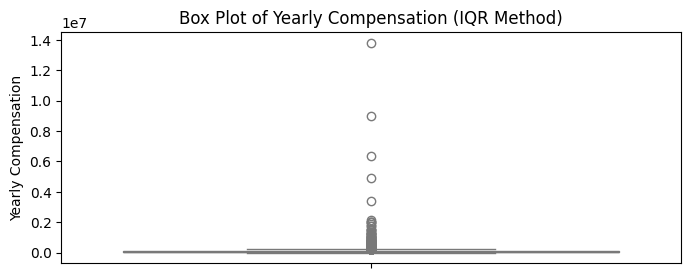

In [11]:
# Plot Box Plot to Visualize Outliers
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, y='ConvertedCompYearly', color="lightblue")
plt.ylabel('Yearly Compensation')
plt.title('Box Plot of Yearly Compensation (IQR Method)')
plt.show()


correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSat`

In [17]:
df_no_outliers = df[(df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound)]
subset_df = df[['ConvertedCompYearly','WorkExp','JobSat']]
correlation_matrix = subset_df.corr()
correlation_matrix


,ConvertedCompYearly,WorkExp,JobSat
ConvertedCompYearly,1.000000,0.153135,0.047504
WorkExp,0.153135,1.000000,0.096829
JobSat,0.047504,0.096829,1.000000


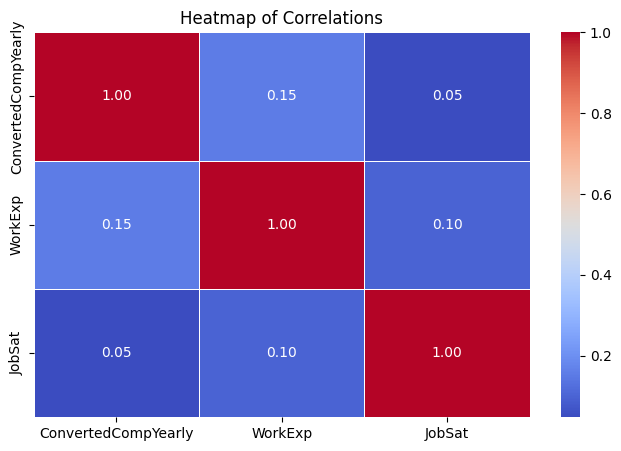

In [19]:
plt.figure(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")

# Labeling
plt.title('Heatmap of Correlations')
plt.show()


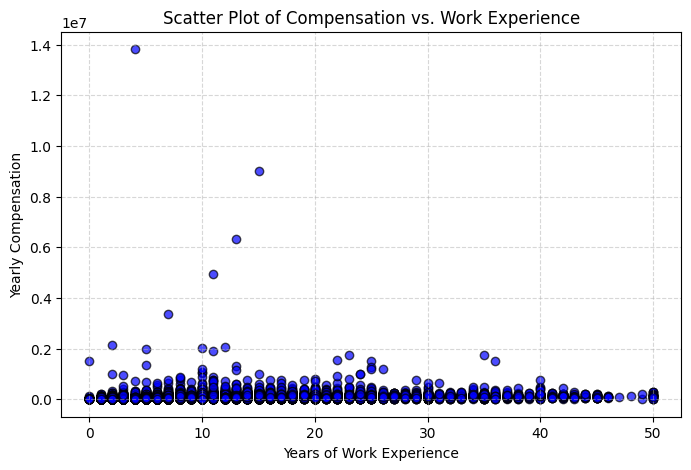

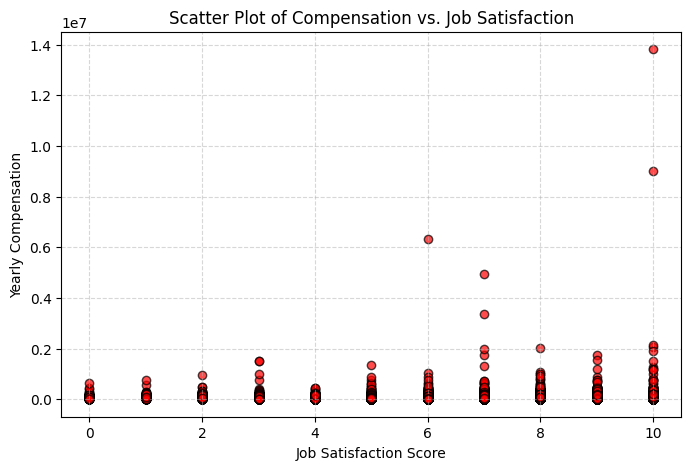

In [ ]:
# Scatter Plot: ConvertedCompYearly vs. WorkExp
plt.figure(figsize=(8, 5))
plt.scatter(df['WorkExp'], df['ConvertedCompYearly'], alpha=0.7, color="blue", edgecolors="black")
plt.xlabel('Years of Work Experience')
plt.ylabel('Yearly Compensation')
plt.title('Scatter Plot of Compensation vs. Work Experience')
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Scatter Plot: ConvertedCompYearly vs. JobSat
plt.figure(figsize=(8, 5))
plt.scatter(df['JobSat'], df['ConvertedCompYearly'], alpha=0.7, color="red", edgecolors="black")
plt.xlabel('Job Satisfaction Score')
plt.ylabel('Yearly Compensation')
plt.title('Scatter Plot of Compensation vs. Job Satisfaction')
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
